In [52]:
import pandas as pd

In [53]:
df = pd.read_csv(r"C:\Users\subha\OneDrive\Desktop\Programming\python\dataAnalytics\Finlatics\DS_Research\Banking\banking_data.csv", low_memory = False)

In [54]:
del df['marital_status']

In [55]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,day_month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,5-May,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,5-May,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,5-May,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,5-May,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,5-May,198,1,-1,0,unknown,no


In [56]:
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'day_month', 'duration', 'campaign',
       'pdays', 'previous', 'poutcome', 'y'],
      dtype='object')

In [9]:
'''
Questions:
-	What is the distribution of age among the clients?
-	How does the job type vary among the clients?
-	What is the marital status distribution of the clients?
-	What is the level of education among the clients?
-	What proportion of clients have credit in default?
-	What is the distribution of average yearly balance among the clients?
-	How many clients have housing loans?
-	How many clients have personal loans?
-	What are the communication types used for contacting clients during the campaign?
-	What is the distribution of the last contact day of the month?
-	How does the last contact month vary among the clients?
-	What is the distribution of the duration of the last contact?
-	How many contacts were performed during the campaign for each client?
-	What is the distribution of the number of days passed since the client was last contacted from a previous campaign?
-	How many contacts were performed before the current campaign for each client?
-	What were the outcomes of the previous marketing campaigns?
-	What is the distribution of clients who subscribed to a term deposit vs. those who did not?
-	Are there any correlations between different attributes and the likelihood of subscribing to a term deposit?

'''

'\nQuestions:\n-\tWhat is the distribution of age among the clients?\n-\tHow does the job type vary among the clients?\n-\tWhat is the marital status distribution of the clients?\n-\tWhat is the level of education among the clients?\n-\tWhat proportion of clients have credit in default?\n-\tWhat is the distribution of average yearly balance among the clients?\n-\tHow many clients have housing loans?\n-\tHow many clients have personal loans?\n-\tWhat are the communication types used for contacting clients during the campaign?\n-\tWhat is the distribution of the last contact day of the month?\n-\tHow does the last contact month vary among the clients?\n-\tWhat is the distribution of the duration of the last contact?\n-\tHow many contacts were performed during the campaign for each client?\n-\tWhat is the distribution of the number of days passed since the client was last contacted from a previous campaign?\n-\tHow many contacts were performed before the current campaign for each client?\

In [23]:
#What is the distribution of age among the clients?

In [28]:
df_age = (df['age'].value_counts())

In [57]:
import matplotlib.pyplot as plt

<Axes: xlabel='age'>

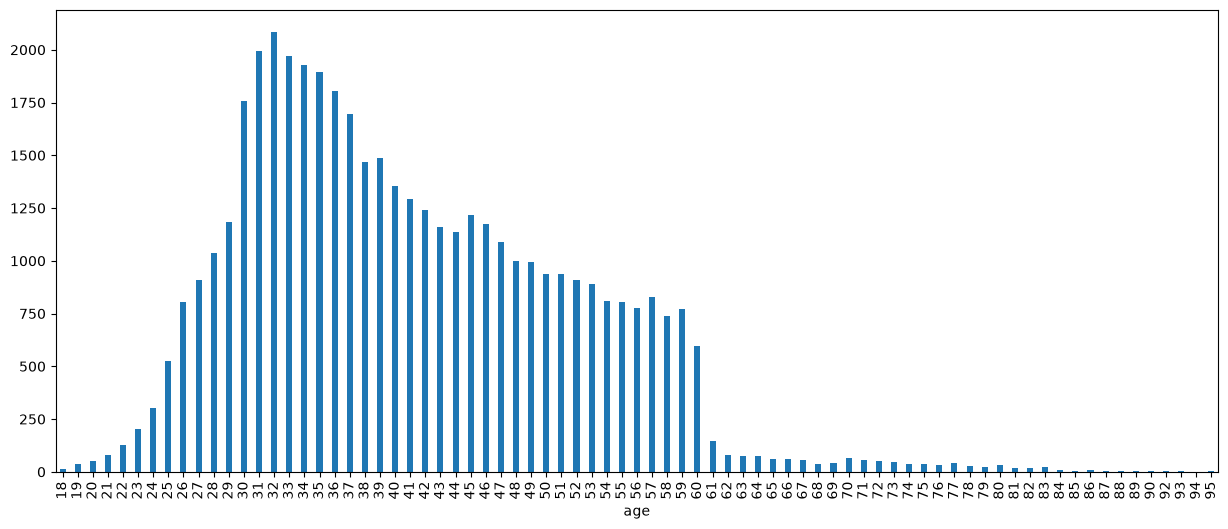

In [33]:
(df_age).sort_index().plot(kind = 'bar', width = 0.4, figsize = (15,6))

In [58]:
del df_age

In [11]:
#How does the job type vary among the clients?

In [50]:
df_job = (df['job'].value_counts())
df_job

job
blue-collar      9732
management       9460
technician       7597
admin.           5171
services         4154
retired          2267
self-employed    1579
entrepreneur     1487
unemployed       1303
housemaid        1240
student           938
unknown           288
Name: count, dtype: int64

In [17]:
import matplotlib.pyplot as plt

<Axes: xlabel='job'>

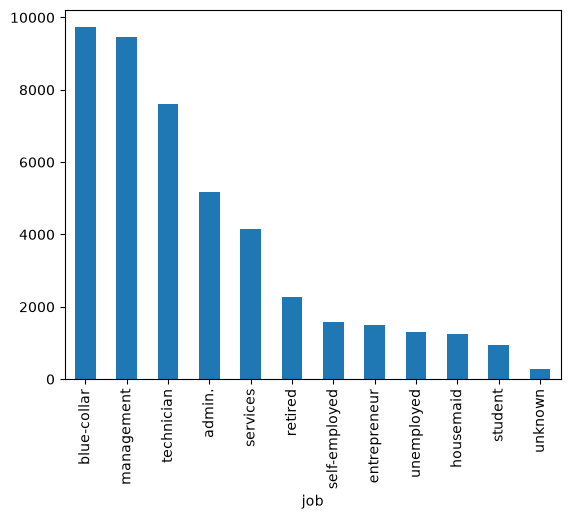

In [22]:
df_job.plot(kind = 'bar')

In [75]:
del df_job

In [34]:
#What is the marital status distribution of the clients?

In [36]:
df_marital = df['marital'].value_counts()

In [42]:
df_marital

marital
married     27216
single      12790
divorced     5207
Name: count, dtype: int64

<Axes: ylabel='count'>

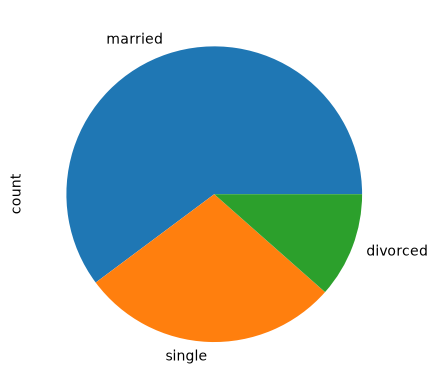

In [43]:
df_marital.plot(kind = 'pie')

In [47]:
del df_marital

In [48]:
#What is the level of education among the clients?

In [71]:
df['education'].value_counts()

education
secondary    23204
tertiary     13301
primary       6851
unknown       1857
Name: count, dtype: int64

In [68]:
df_edu = df['education'].value_counts(normalize = True)

In [69]:
df_edu

education
secondary    0.513215
tertiary     0.294185
primary      0.151527
unknown      0.041072
Name: proportion, dtype: float64

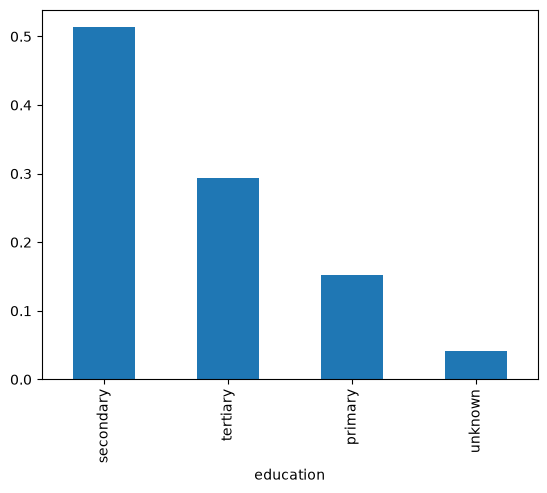

In [73]:
df_edu.plot(kind = 'bar')
plt.ylabel = 'Proportion of all people in dataset'
plt.show()

In [74]:
del df_edu

In [76]:
#What proportion of clients have credit in default?

In [78]:
df['default'].value_counts(normalize = True)

default
no     0.981975
yes    0.018025
Name: proportion, dtype: float64

In [79]:
#What is the distribution of average yearly balance among the clients?

In [115]:
DF = pd.DataFrame(df['balance'].value_counts().sort_index())
DF

,count
balance,
-8019,1
-6847,1
-4057,1
-3372,1
-3313,1
...,...
66721,1
71188,1
81204,2


C:\Users\subha\AppData\Local\Temp\ipykernel_16240\3780654894.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  result = DF.groupby(grouped).sum()


<Axes: >

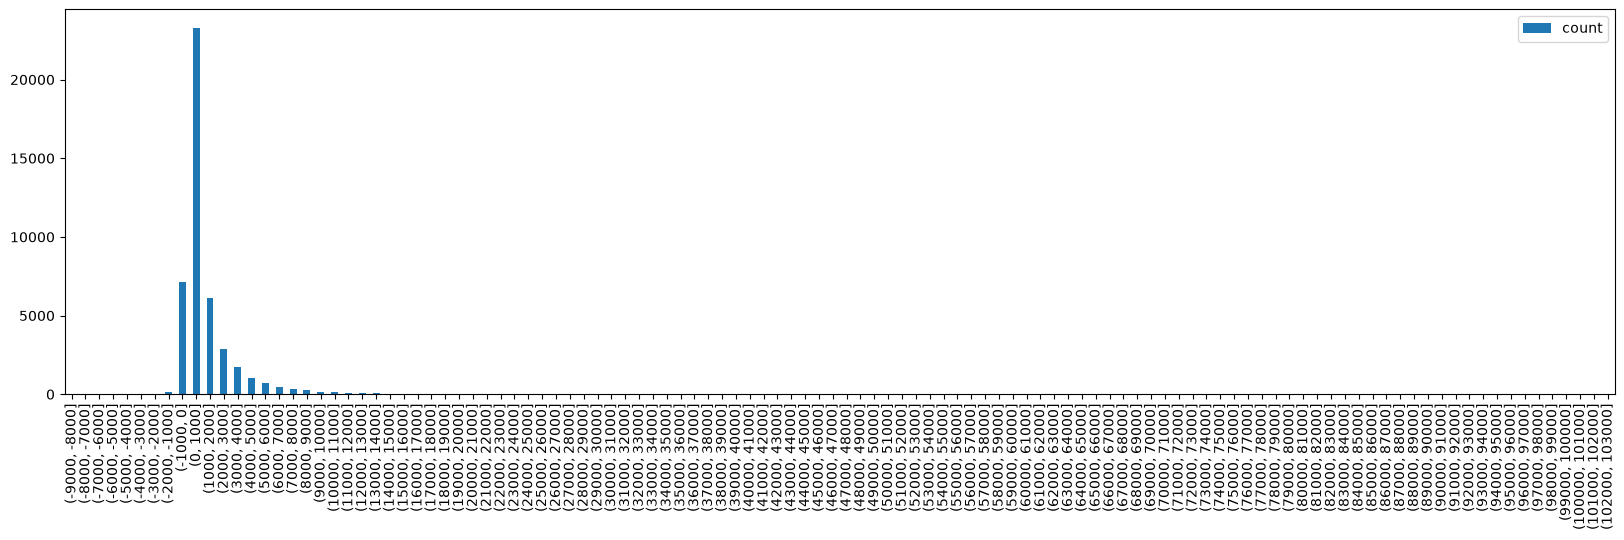

In [102]:
grouped = pd.cut(
    DF.index,
    bins=[1000*i for i in range (-9, 104)]
)

result = DF.groupby(grouped).sum()

result.plot(kind = 'bar', figsize = (20, 5))

In [105]:
result.sort_values('count', ascending = False).head(20)

,count
"(0, 1000]",23302
"(-1000, 0]",7136
"(1000, 2000]",6132
"(2000, 3000]",2891
"(3000, 4000]",1713
"(4000, 5000]",1053
"(5000, 6000]",737
"(6000, 7000]",482
"(7000, 8000]",347
"(8000, 9000]",286


<Axes: >

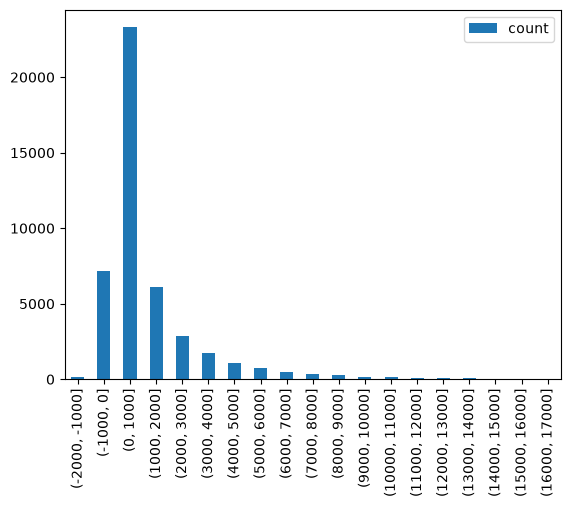

In [108]:
result[result['count']>40].sort_index().plot(kind = 'bar')

In [121]:
grouped = pd.cut(
    DF.index,
    bins=[100*i for i in range (-10, 51)]
)

result = DF.groupby(grouped).sum()

C:\Users\subha\AppData\Local\Temp\ipykernel_16240\2295968954.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  result = DF.groupby(grouped).sum()


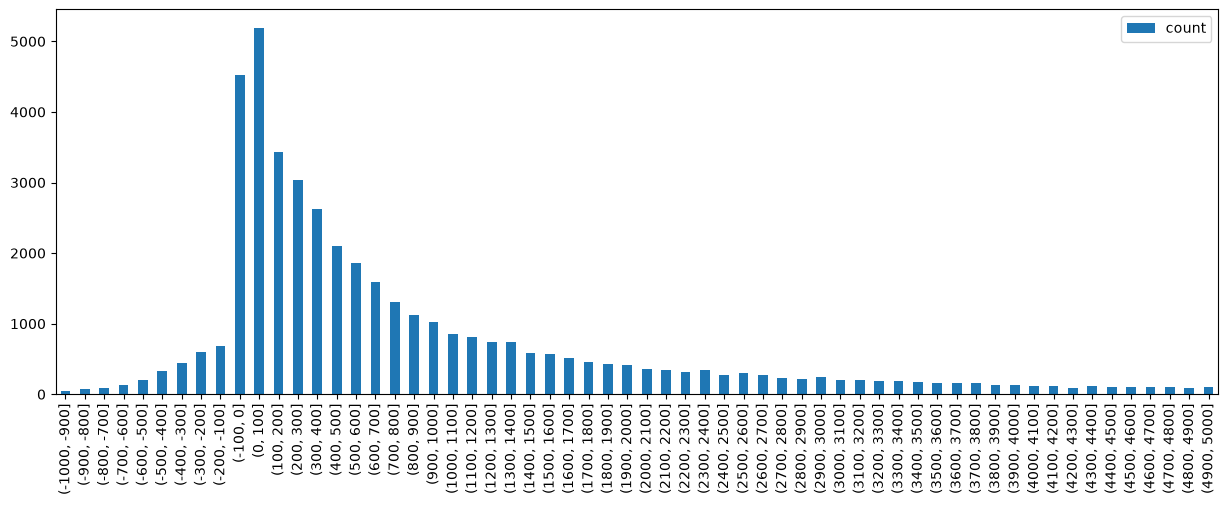

In [125]:
result.plot(kind = 'bar', figsize = (15,5))
plt.xlabel = 'average balance'
plt.show()

In [126]:
del result

In [127]:
del DF

In [128]:
del grouped

In [112]:
#How many clients have housing loans?

In [129]:
df['housing'].value_counts()

housing
yes    25130
no     20086
Name: count, dtype: int64

In [130]:
#How many clients have personal loans?

In [131]:
df['loan'].value_counts()

loan
no     37972
yes     7244
Name: count, dtype: int64

In [132]:
#What are the communication types used for contacting clients during the campaign?

In [133]:
df['contact'].value_counts()

contact
cellular     29290
unknown      13020
telephone     2906
Name: count, dtype: int64

In [134]:
#What is the distribution of the last contact day of the month?

In [138]:
df_day = pd.DataFrame(df['day'].value_counts().sort_index())

In [140]:
df_day.head()

,count
day,
1,322
2,1293
3,1079
4,1445
5,1910


<Axes: xlabel='day'>

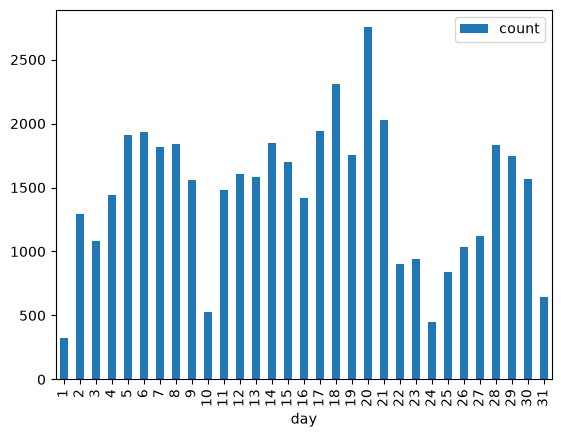

In [141]:
df_day.plot(kind = 'bar')

In [143]:
del df_day

In [144]:
#How does the last contact month vary among the clients?

In [148]:
df_mon = pd.DataFrame(df['month'].value_counts())

In [149]:
type(df_mon)

pandas.core.frame.DataFrame

In [152]:
df_mon.index = df_mon.index.map(
{
    'jan':1,
    'feb':2,
    'mar':3,
    'apr':4,
    'may':5,
    'jun':6,
    'jul':7,
    'aug':8,
    'sep':9,
    'oct':10,
    'nov':11,
    'dec':12
})

In [155]:
df_mon.sort_index(inplace = True)

In [156]:
df_mon

,count
month,
1,1403
2,2649
3,477
4,2932
5,13766
6,5341
7,6895
8,6247
9,579


<Axes: xlabel='month'>

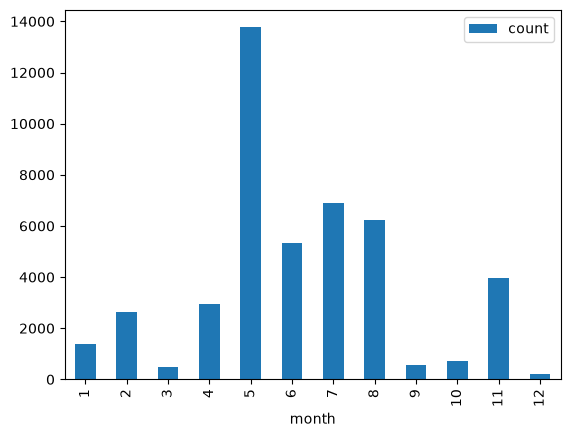

In [157]:
df_mon.plot(kind = 'bar')

In [158]:
del df_mon

In [159]:
#What is the distribution of the duration of the last contact?

In [177]:
df_dur = pd.DataFrame(df['duration'].value_counts())

In [178]:
df_dur.head()

,count
duration,
124,188
90,184
89,177
104,175
122,175


In [179]:
df_dur.sort_index(inplace = True)

In [181]:
df_dur.head()

,count
duration,
0,3
1,2
2,3
3,4
4,15


In [180]:
df_dur.tail()

,count
duration,
3366,1
3422,1
3785,1
3881,1
4918,1


In [192]:
grouped = pd.cut(
    df_dur.index,
    bins=[40*i for i in range (0, 41)]
)

result = df_dur.groupby(grouped).sum()

C:\Users\subha\AppData\Local\Temp\ipykernel_16240\2591395719.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  result = df_dur.groupby(grouped).sum()


<Axes: xlabel='duration(seconds)', ylabel='number of client'>

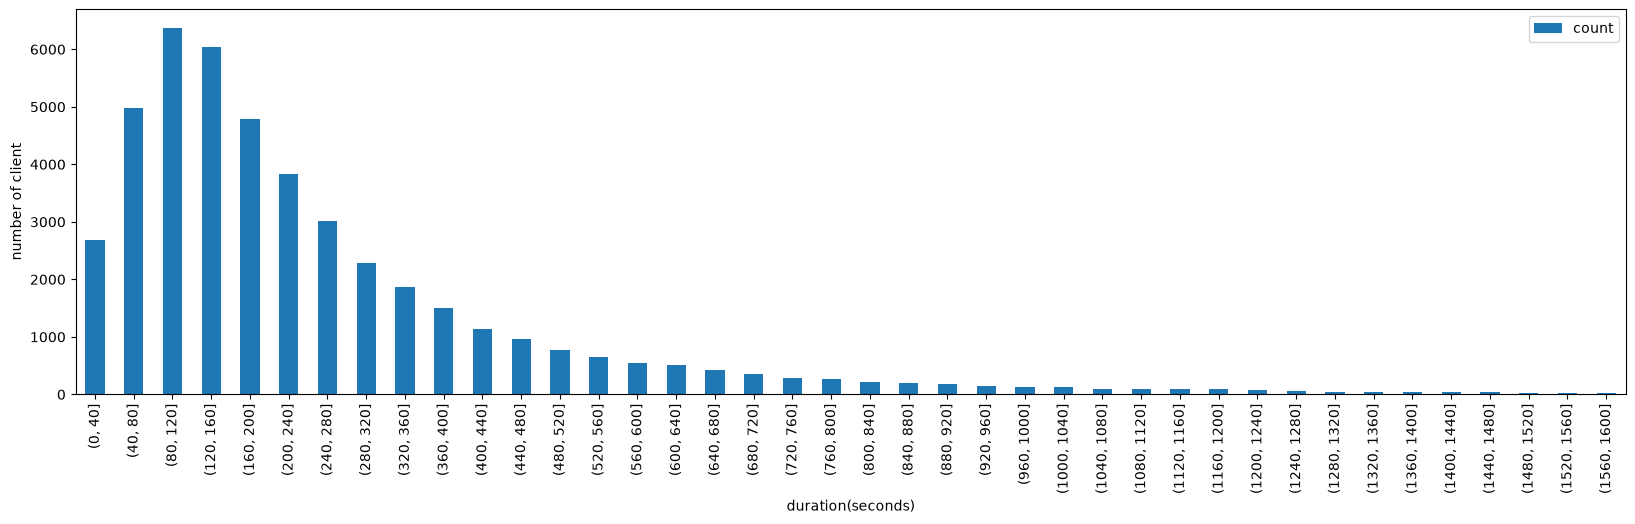

In [195]:
result.plot(kind = 'bar', figsize = (20,5), xlabel = 'duration(seconds)', ylabel = 'number of client')

In [196]:
del df_dur
del grouped
del result

In [197]:
#How many contacts were performed during the campaign for each client?

In [199]:
cont = df['campaign'].value_counts()

In [200]:
cont.head(15)

campaign
1     17548
2     12506
3      5521
4      3522
5      1764
6      1291
7       735
8       540
9       327
10      266
11      201
12      155
13      133
14       93
15       84
Name: count, dtype: int64

<Axes: xlabel='Number of times contacted', ylabel='Number of person'>

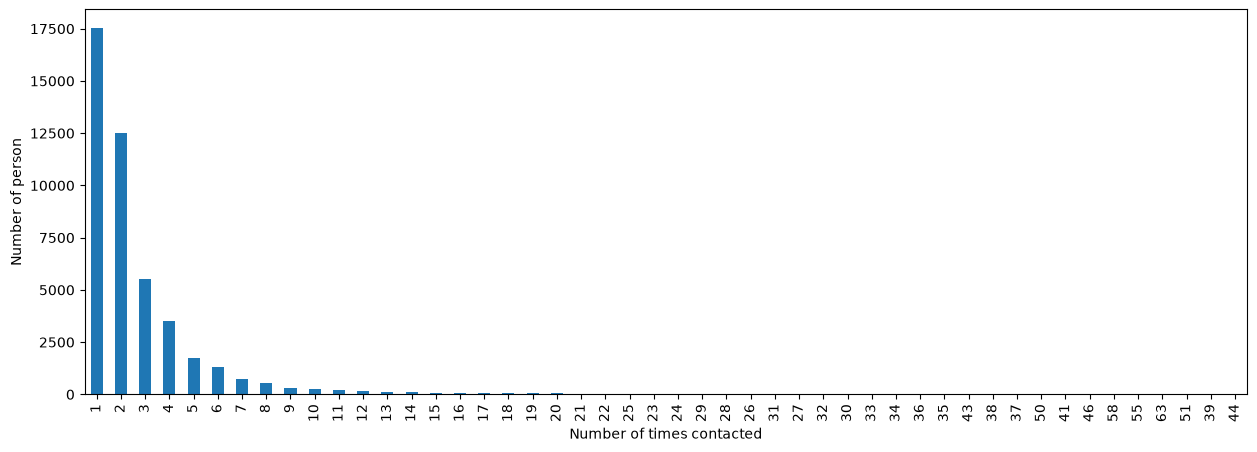

In [202]:
cont.plot(kind = 'bar', figsize = (15,5),xlabel = 'Number of times contacted', ylabel = 'Number of person')

In [203]:
del cont

In [204]:
#What is the distribution of the number of days passed since the client was last contacted from a previous campaign?

In [209]:
count = pd.DataFrame(df['pdays'].value_counts())

In [213]:
count = count[count.index!=-1]

In [214]:
count.sort_index()

,count
pdays,
1,15
2,37
3,1
4,2
5,11
...,...
838,1
842,1
850,1


In [220]:
grouped = pd.cut(
    count.index,
    bins=[10*i for i in range (0, 61)]
)

result = count.groupby(grouped).sum()

C:\Users\subha\AppData\Local\Temp\ipykernel_16240\759684680.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  result = count.groupby(grouped).sum()


<Axes: xlabel='Number of days passed after last contact', ylabel='Number of clients'>

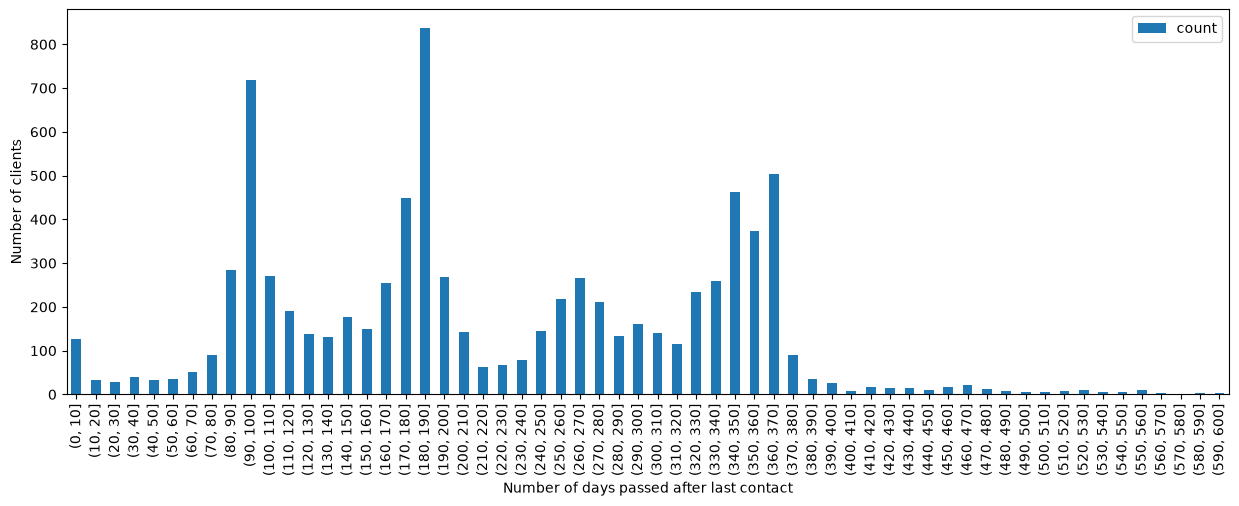

In [221]:
result.plot(kind = 'bar',figsize = (15,5),xlabel = 'Number of days passed after last contact', ylabel = 'Number of clients')

In [222]:
#How many contacts were performed before the current campaign for each client?

In [224]:
prev = df['previous'].value_counts()
prev

previous
0      36956
1       2772
2       2106
3       1142
4        715
5        459
6        278
7        205
8        130
9         92
10        67
11        65
12        44
13        38
15        20
14        19
17        15
16        13
19        11
20         8
23         8
18         6
22         6
24         5
27         5
21         4
29         4
25         4
30         3
38         2
37         2
26         2
28         2
51         1
275        1
58         1
32         1
40         1
55         1
35         1
41         1
Name: count, dtype: int64

<Axes: xlabel='contacts performed before this campaign for a client', ylabel='Number of clients'>

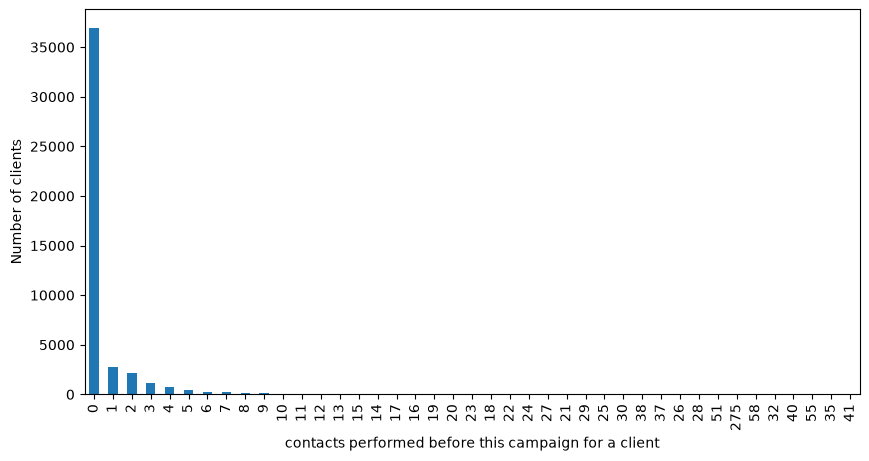

In [226]:
prev.plot(kind = 'bar',figsize = (10,5),xlabel = 'contacts performed before this campaign for a client', ylabel = 'Number of clients')

In [227]:
#What were the outcomes of the previous marketing campaigns?

In [229]:
df['poutcome'].value_counts()

poutcome
unknown    36961
failure     4902
other       1840
success     1513
Name: count, dtype: int64

In [230]:
#What is the distribution of clients who subscribed to a term deposit vs. those who did not?

In [231]:
df['y'].value_counts()

y
no     39922
yes     5294
Name: count, dtype: int64

In [234]:
dist = df['y'].value_counts(normalize = True)
dist

y
no     0.882918
yes    0.117082
Name: proportion, dtype: float64

<Axes: title={'center': 'clients subscribed vs. not subscribed'}, ylabel='proportion'>

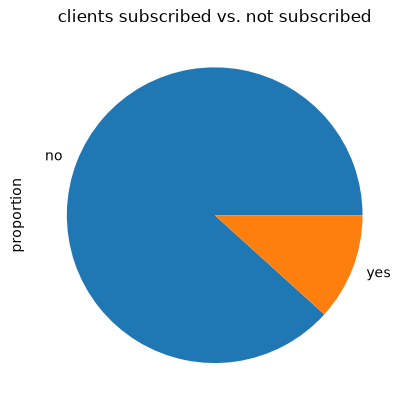

In [237]:
dist.plot(kind = 'pie', title = 'clients subscribed vs. not subscribed')

In [ ]:
#Are there any correlations between different attributes and the likelihood of subscribing to a term deposit?

In [238]:
df_corr = df.copy()

df_corr['y'] = df_corr['y'].map({'no': 0, 'yes': 1})

In [239]:
num_cols = ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous', 'y']
corr = df_corr[num_cols].corr()

In [240]:
corr['y'].sort_values(ascending=False)

y           1.000000
duration    0.394387
pdays       0.103699
previous    0.093576
balance     0.052821
age         0.025648
day        -0.028307
campaign   -0.073294
Name: y, dtype: float64

In [241]:
data = corr['y'].drop('y').sort_values()

<Axes: title={'center': 'Correlation of Numerical Variables with Term Deposit Subscription'}, xlabel='Correlation with Subscription'>

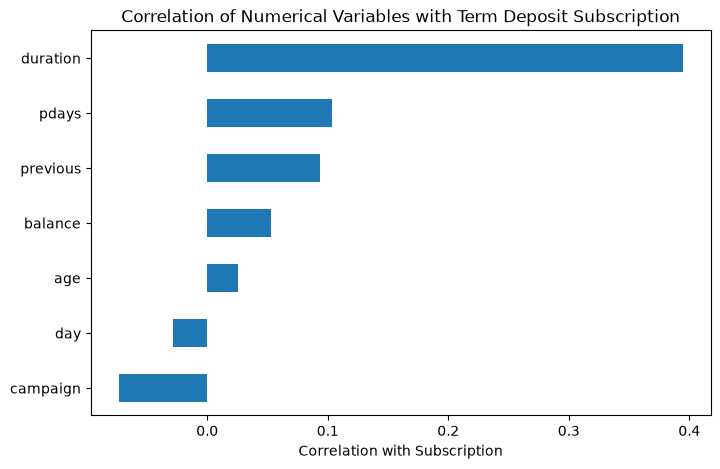

In [242]:
data.plot(kind='barh',figsize=(8,5), xlabel = 'Correlation with Subscription', title = 'Correlation of Numerical Variables with Term Deposit Subscription')

In [49]:
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'day_month', 'duration', 'campaign',
       'pdays', 'previous', 'poutcome', 'y'],
      dtype='object')

In [142]:
'''
age: This column represents the age of the bank client. It's a numeric variable indicating the age in years.

job: This column indicates the type of job the client has. It's a categorical variable with options such as "admin.", "unknown", "unemployed", "management", etc.

marital: This column represents the marital status of the client. It's a categorical variable with options such as "married", "divorced", or "single".

education: This column indicates the level of education of the client. It's a categorical variable with options such as "unknown", "secondary", "primary", or "tertiary".

default: This column indicates whether the client has credit in default. It's a binary variable with options "yes" or "no".

balance: This column represents the average yearly balance in euros for the client. It's a numeric variable.

housing: This column indicates whether the client has a housing loan. It's a binary variable with options "yes" or "no".

loan: This column indicates whether the client has a personal loan. It's a binary variable with options "yes" or "no".

contact: This column represents the type of communication used to contact the client. It's a categorical variable with options such as "unknown", "telephone", or "cellular".

day: This column represents the last contact day of the month. It's a numeric variable.

month: This column represents the last contact month of the year. It's a categorical variable with options such as "jan", "feb", "mar", etc.

duration: This column represents the duration of the last contact in seconds. It's a numeric variable.

campaign: This column represents the number of contacts performed during this campaign and for this client. It's a numeric variable.

pdays: This column represents the number of days that passed by after the client was last contacted from a previous campaign. It's a numeric variable where -1 means the client was not previously contacted.

previous: This column represents the number of contacts performed before this campaign and for this client. It's a numeric variable.

poutcome: This column represents the outcome of the previous marketing campaign. It's a categorical variable with options such as "unknown", "other", "failure", or "success".

y: This column is the target variable and indicates whether the client has subscribed to a term deposit. It's a binary variable with options "yes" or "no".

'''

'\nage: This column represents the age of the bank client. It\'s a numeric variable indicating the age in years.\n\njob: This column indicates the type of job the client has. It\'s a categorical variable with options such as "admin.", "unknown", "unemployed", "management", etc.\n\nmarital: This column represents the marital status of the client. It\'s a categorical variable with options such as "married", "divorced", or "single".\n\neducation: This column indicates the level of education of the client. It\'s a categorical variable with options such as "unknown", "secondary", "primary", or "tertiary".\n\ndefault: This column indicates whether the client has credit in default. It\'s a binary variable with options "yes" or "no".\n\nbalance: This column represents the average yearly balance in euros for the client. It\'s a numeric variable.\n\nhousing: This column indicates whether the client has a housing loan. It\'s a binary variable with options "yes" or "no".\n\nloan: This column indic

In [ ]:
del df_corr

In [ ]:
del corr

In [ ]:
del data

In [ ]:
del df